In [1]:
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.stats as st
from scipy.interpolate import interp1d
from stis_extract import *

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/CONTACT/STIS/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Latest visit

Latest visit only

In [4]:
qso_name = 'J035721'

In [5]:
d_latest = coadd_1dspec(qso_name, ['of8g62010', 'of8g62020'], 4)

/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:337: RuntimeWarning: invalid value encountered in divide
  net_ct_rates_stitch = net_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:338: RuntimeWarning: divide by zero encountered in divide
  err_u_ct_rates_stitch = err_u_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:338: RuntimeWarning: invalid value encountered in divide
  err_u_ct_rates_stitch = err_u_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:339: RuntimeWarning: invalid value encountered in divide
  err_d_ct_rates_stitch = err_d_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extract/stis_extract.py:340: RuntimeWarning: divide by zero encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
/Users/thepoetoftwilight/Documents/CUBS/Code/STIS_extrac

All visits

In [6]:
d_all = coadd_1dspec(qso_name,['OF8G32010', 'OF8G30010', 'OF8G30020',
                               'OF8G30030','OF8G60010', 'OF8G62010', 'OF8G62020'], 4)

Compare

In [7]:
#d_all['error'][~np.isnan(d_all['error'])]

In [8]:
#d_all['error_u'][~np.isnan(d_all['error_u'])]

In [9]:
#d_all['error_d'][~np.isnan(d_all['error_d'])]

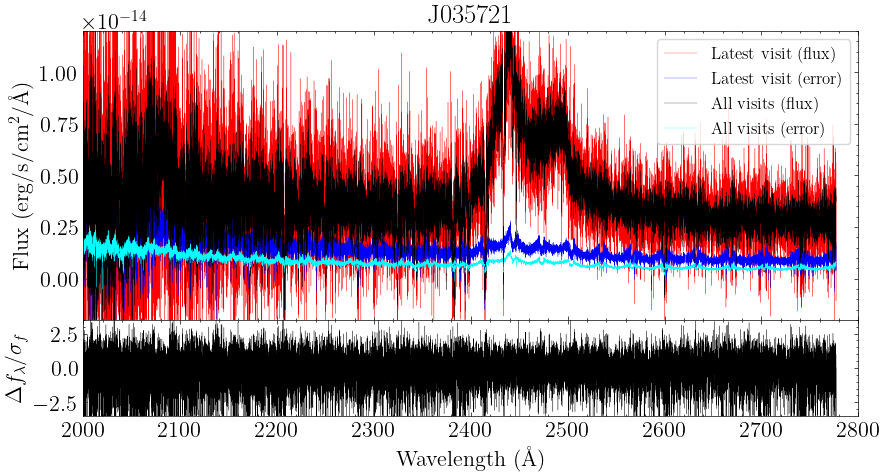

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_latest['wave'], d_latest['flux'], where='mid', color='red', alpha=1, lw=.2, label="Latest visit (flux)")
axes[0].step(d_latest['wave'], d_latest['error'], where='mid', color='blue', alpha=1, lw=.2, label="Latest visit (error)")

axes[0].step(d_all['wave'], d_all['flux'], where='mid', color='black', alpha=1, lw=.2, label="All visits (flux)")
axes[0].step(d_all['wave'], d_all['error'], where='mid', color='cyan', alpha=1, lw=.2, label="All visits (error)")

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')
axes[0].set_title(r'J035721')

axes[0].legend(loc='upper right')
axes[0].set_xlim(2000,2800)
axes[0].set_ylim(-.2e-14,1.2e-14)
axes[0].legend()

axes[1].step(d_all['wave'], (d_latest['flux']-d_all['flux'])/np.sqrt(d_latest['error']**2+d_all['error']**2), 
             alpha=1,lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-3.5, 3.5)
plt.subplots_adjust(wspace=0.2, hspace=0)

# Compare with Zhijie's stitch

In [11]:
d_zq = fits.open(rootdir+'J035721/J0357_ext4_all_plotabs.fits')[1].data

d_zq_interp = {}

d_zq_interp['wave'] = d_all['wave']
d_zq_interp['flux'] = interp1d(d_zq['wave'], d_zq['flux'], fill_value='extrapolate')(d_zq_interp['wave'])
d_zq_interp['error'] = np.sqrt(interp1d(d_zq['wave'], d_zq['error']**2, fill_value='extrapolate')(d_zq_interp['wave']))
d_zq_interp['error_u'] = np.sqrt(interp1d(d_zq['wave'], d_zq['error_u']**2, fill_value='extrapolate')(d_zq_interp['wave']))
d_zq_interp['error_d'] = np.sqrt(interp1d(d_zq['wave'], d_zq['error_d']**2, fill_value='extrapolate')(d_zq_interp['wave']))
d_zq_interp['counts_total'] = interp1d(d_zq['wave'], d_zq['counts_total'], fill_value='extrapolate')(d_zq_interp['wave'])
d_zq_interp['counts_net'] = interp1d(d_zq['wave'], d_zq['counts_net'], fill_value='extrapolate')(d_zq_interp['wave'])

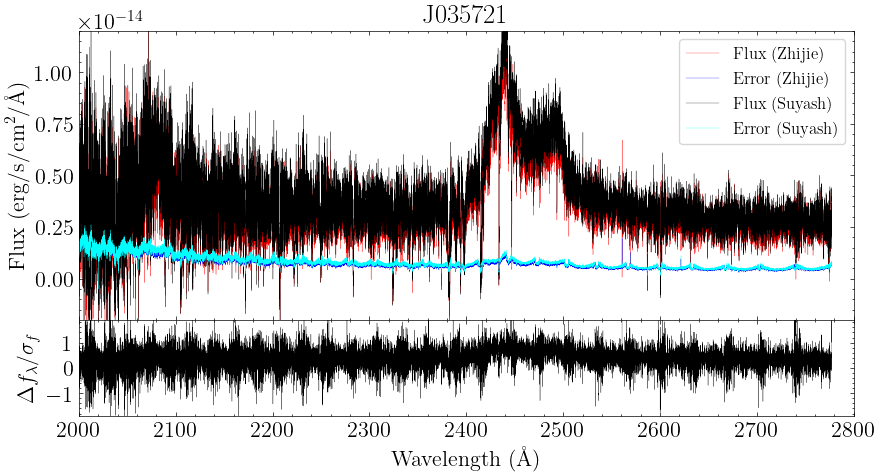

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_zq['wave'], d_zq['flux'], where='mid', color='red', alpha=1, lw=.2, label="Flux (Zhijie)")
axes[0].step(d_zq['wave'], d_zq['error'], where='mid', color='blue', alpha=1, lw=.2, label="Error (Zhijie)")

axes[0].step(d_all['wave'], d_all['flux'], where='mid', color='black', alpha=1, lw=.2, label="Flux (Suyash)")
axes[0].step(d_all['wave'], d_all['error'], where='mid', color='cyan', alpha=1, lw=.2, label="Error (Suyash)")

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

#axes[0].legend(loc='upper right')
axes[0].set_xlim(2000,2800)
axes[0].set_ylim(-.2e-14,1.2e-14)
axes[0].legend()
axes[0].set_title(r'J035721')

axes[1].step(d_all['wave'], (d_all['flux']-d_zq_interp['flux'])/np.sqrt(d_all['error']**2+d_zq_interp['error']**2), 
             alpha=1,lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-1.9, 1.9)
plt.subplots_adjust(wspace=0.2, hspace=0)

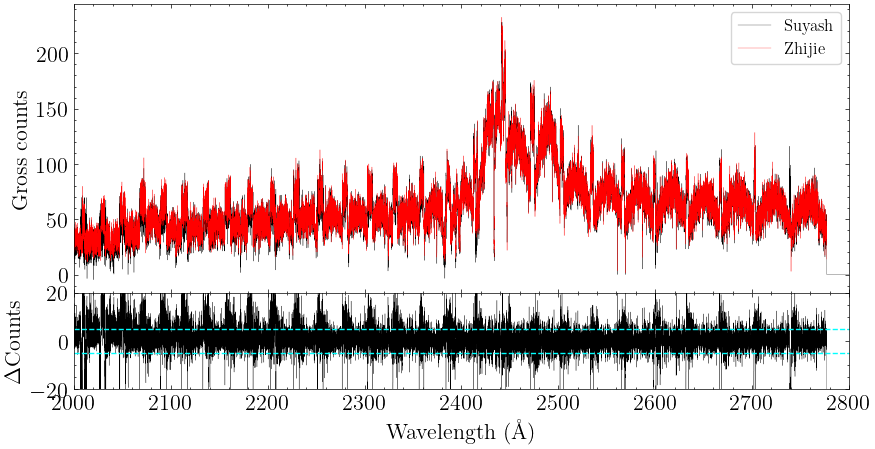

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_all['wave'], d_all['counts_total'], where='mid', color='black', alpha=1, lw=.2, label="Suyash")
axes[0].step(d_zq['wave'], d_zq['counts_total'], where='mid', color='red', alpha=1, lw=.2, label="Zhijie")

axes[0].set_xlim(2000,2800)

axes[0].legend()

axes[0].set_ylabel(r'Gross counts')

axes[1].step(d_all['wave'], d_zq_interp['counts_total']-d_all['counts_total'], 
             alpha=1,lw=.2, color='black')

axes[1].axhline(5, color='cyan', linestyle='--')
axes[1].axhline(-5, color='cyan', linestyle='--')

axes[1].set_ylabel(r'$\Delta \mathrm{Counts}$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-20, 20)
plt.subplots_adjust(wspace=0.2, hspace=0)

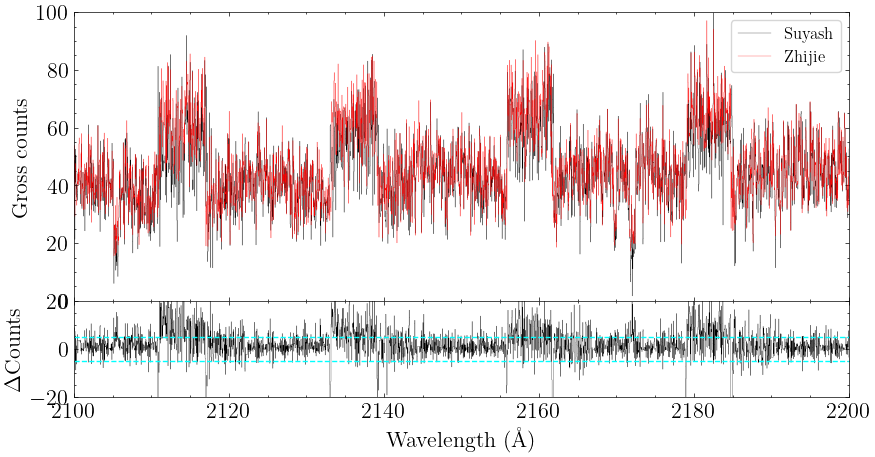

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_all['wave'], d_all['counts_total'], where='mid', color='black', alpha=1, lw=.2, label="Suyash")
axes[0].step(d_zq['wave'], d_zq['counts_total'], where='mid', color='red', alpha=1, lw=.2, label="Zhijie")

axes[0].legend()

axes[0].set_xlim(2100,2200)
axes[0].set_ylim(0,100)
axes[0].set_ylabel(r'Gross counts')

axes[1].step(d_all['wave'], d_zq_interp['counts_total']-d_all['counts_total'], 
             alpha=1,lw=.2, color='black')

axes[1].axhline(5, color='cyan', linestyle='--')
axes[1].axhline(-5, color='cyan', linestyle='--')

axes[1].set_ylabel(r'$\Delta \mathrm{Counts}$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-20, 20)
plt.subplots_adjust(wspace=0.2, hspace=0)

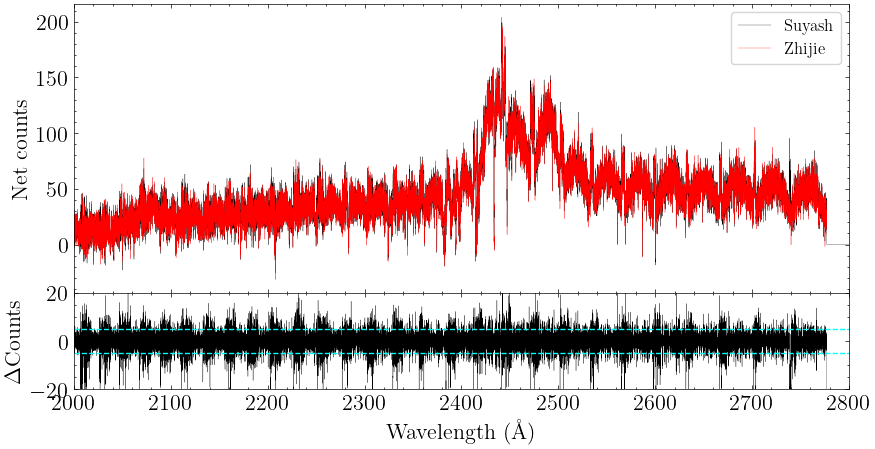

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_all['wave'], d_all['counts_net'], where='mid', color='black', alpha=1, lw=.2, label="Suyash")
axes[0].step(d_zq['wave'], d_zq['counts_net'], where='mid', color='red', alpha=1, lw=.2, label="Zhijie")

axes[0].set_xlim(2000,2800)

axes[0].legend()
axes[0].set_ylabel(r'Net counts')

axes[1].step(d_all['wave'], d_zq_interp['counts_net']-d_all['counts_net'], 
             alpha=1,lw=.2, color='black')


axes[1].axhline(5, color='cyan', linestyle='--')
axes[1].axhline(-5, color='cyan', linestyle='--')

axes[1].set_ylabel(r'$\Delta \mathrm{Counts}$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-20, 20)
plt.subplots_adjust(wspace=0.2, hspace=0)

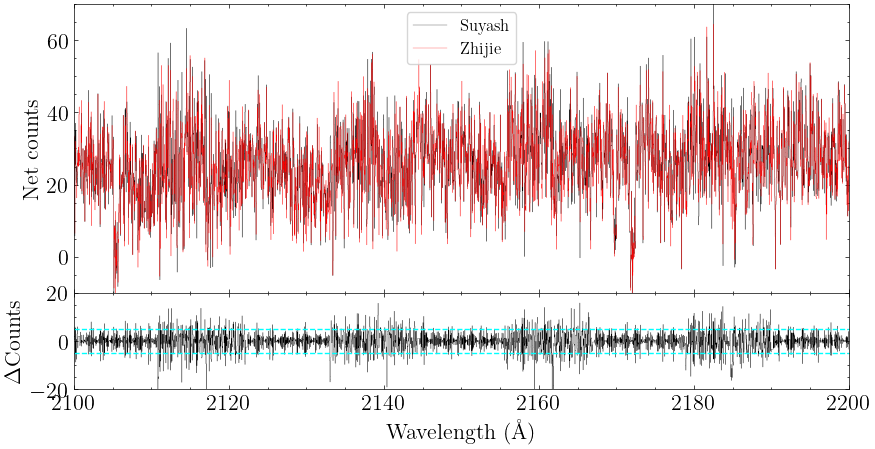

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(d_all['wave'], d_all['counts_net'], where='mid', color='black', alpha=1, lw=.2, label="Suyash")
axes[0].step(d_zq['wave'], d_zq['counts_net'], where='mid', color='red', alpha=1, lw=.2, label="Zhijie")

axes[0].legend()
axes[0].set_xlim(2100,2200)
axes[0].set_ylim(-10,70)

axes[0].set_ylabel(r'Net counts')

axes[1].step(d_all['wave'], d_zq_interp['counts_net']-d_all['counts_net'], 
             alpha=1,lw=.2, color='black')


axes[1].axhline(5, color='cyan', linestyle='--')
axes[1].axhline(-5, color='cyan', linestyle='--')

axes[1].set_ylabel(r'$\Delta \mathrm{Counts}$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-20, 20)
plt.subplots_adjust(wspace=0.2, hspace=0)

## Flux calculation

In [10]:
idx = wav_stitch_all<2730

flux_lam_ref = 3631/(3.34*1e4*wav_stitch_all[idx]**2)
dwav = wav_stitch_all[idx][1:]-wav_stitch_all[idx][:-1]
wav_int = .5*(wav_stitch_all[idx][1:]+wav_stitch_all[idx][:-1])
f_int = .5*(flux_stitch_all[idx][1:]+flux_stitch_all[idx][:-1])
f_ref_int = .5*(flux_lam_ref[1:]+flux_lam_ref[:-1])

In [11]:
mag = -2.5*np.log10(np.nansum(wav_int*f_int*dwav)/np.nansum(wav_int*f_ref_int*dwav))

In [12]:
mag

16.74224521109467

Convert back to flux using pivot wavelength

In [13]:
for i in range(len(flux_stitch_all)):
    
    if ~np.isnan(flux_stitch_all[i]):
        w0 = wav_stitch_all[i]
        break

In [14]:
w1 = 2730

In [15]:
wav_p = np.sqrt((w1-w0)/(w0**-1 - w1**-1))

In [16]:
f_lam_nuv = (3631*10**(-mag/2.5))/(3.34e4*wav_p**2)

In [17]:
f_lam_nuv

4.025817183384475e-15

## Plotabs conversion

In [18]:
idx = (~np.isnan(flux_stitch_all))&(~np.isnan(err_stitch_all))

In [19]:
save_spec1d_fits(rootdir+'J035721/', 'J035721_es=4', wav_stitch_all[idx], flux_stitch_all[idx], err_stitch_all[idx])